# Import modules and functions

In [22]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [23]:
from plot_functions import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Final Time Snapshots

### Choose parameters and simulation data

In [24]:
#PARAMETERS
Nx = 4
Ny = 4
N = Nx*Ny      # Number of sites 
start = 'random'    # 'random' or 'custom' 
J = 1
V = 0.0
dt = 0.02
p = 2*dt
phi = 0.5
steps = 1000
tot_shots = 10000    # all the shots available
sample_shots = 10000   # subsample shots
statistics = 'fermions'   # 'bosons' or 'fermions'
data = 'Lindblad'           #'H1', 'Noisy', 'Ideal', 'Lindblad'

# load densities and currents from data directory
if data == 'H1':
    path = '../data/data_H1/'
    filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{tot_shots}.h5'
    n_avg, n_sem, currents, currents_sem, bonds = get_device_observables(path, filename, statistics, sample_shots)

elif data == 'Noisy':
    path = '../data/data_Emulator/'
    filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{tot_shots}.h5'
    n_avg, n_sem, currents, currents_sem, bonds = get_device_observables(path, filename, statistics, sample_shots)

elif data == 'Ideal':
    path = '../data/data_numerics/'
    filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{tot_shots}_trotter.h5'
    n_avg, n_sem, currents, currents_sem, bonds = get_numerics_observables(path, filename, sample_shots)

elif data == 'Lindblad':
    path = '../data/data_numerics/'
    filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{tot_shots}.h5'
    n_avg, n_sem, currents, currents_sem, bonds = get_numerics_observables(path, filename, sample_shots)


### Plot Snapshot

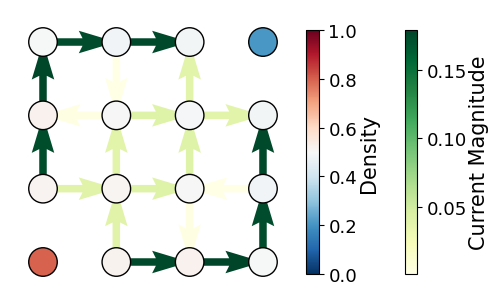

In [25]:
marker_size = 750 * (3/Nx)**2  # Size of the markers for the density plot
arrow_width = 0.035 * 3/Nx  # Width of the arrows in the quiver plot

# single line definition of empty lists for X, Y, U, V, C
X = []; Y = []; U1 = []; U2 = []; C = []
for i, bond in enumerate(bonds):

    # skip bonds connected to source / drain
    if (0 in bond) or (N-1 in bond):
        continue

    # convert back from n to x,y coordinates
    x1, y1 = bond[0] % Nx, bond[0] // Nx
    x2, y2 = bond[1] % Nx, bond[1] // Nx

    C.append(np.abs(currents[i]))

    if np.real(currents[i]) > 0:
        X.append(x1)
        Y.append(y1)
        U1.append(x2-x1)
        U2.append(y2-y1)
    else:
        X.append(x2)
        Y.append(y2)
        U1.append(x1-x2)
        U2.append(y1-y2)


fig, ax = plt.subplots(figsize = (6,6))


p1 = ax.quiver(X, Y, U1, U2, C, cmap="YlGn", angles='xy', scale_units='xy', scale=1, width=arrow_width)
cb1 = plt.colorbar(p1, ax=ax, orientation='vertical', shrink=0.53, pad=0.1)
cb1.ax.tick_params(labelsize=13)
cb1.set_label('Current Magnitude', labelpad=1, fontsize = 15)

X = []; Y = []; C = []
for x in range(Nx):
    for y in range(Ny):
        n = x % Nx + y*Nx
        X.append(x)
        Y.append(y)
        C.append(n_avg[n])

p2 = ax.scatter(X, Y, c=C, cmap="RdBu_r", s=marker_size, edgecolors= "black", vmin=0, vmax=1)
cb2 = plt.colorbar(p2, ax=ax, orientation='vertical', shrink=0.53, pad=0.03)
cb2.set_ticks(np.arange(0, 1.1, 0.2))
cb2.ax.tick_params(labelsize=13)
cb2.set_label('Density', labelpad=1, fontsize = 15)

# Add automatic padding to prevent cutoff
ax.margins(0.2 * 3/Nx)  # Add padding around the data
# Alternatively, you could use: ax.set_xlim(-0.5, Nx-0.5); ax.set_ylim(-0.5, Ny-0.5)

ax.set_axis_off()
ax.set_aspect('equal')

# plt.savefig(f"figures/snapshot_{data}_{statistics}_{data}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_tajectories{sample_shots}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=500)

# Density and Current Traces

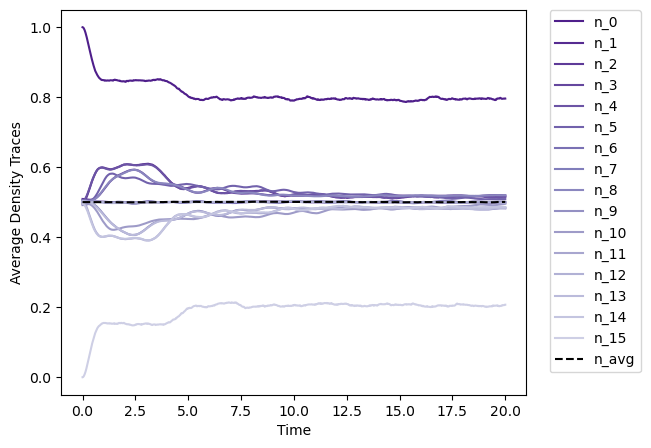

In [26]:
if path == '../data/data_numerics/':
    n_avg_step = load_key_from_hdf5(path+filename, "n_avg")
    # n_sq_avg = load_key_from_hdf5(path+filename, "n_sq_avg")
    # n_sem_step = np.sqrt(n_sq_avg - n_avg_step**2)/np.sqrt(tot_shots)
    t_list = load_key_from_hdf5(path+filename, "t_list")

    plt.figure(figsize=(6,5))
    colors = plt.cm.Purples(np.linspace(0.9, 0.3, 16))
    for i in range(N):
        # plt.fill_between(t_list, n_avg_step[i,:] - n_sem_step[i,:], n_avg_step[i,:] + n_sem_step[i,:], alpha=0.2, color=colors[i])
        plt.plot(t_list, n_avg_step[i,:],  color=colors[i], label=f"n_{i}")

    plt.plot(t_list, np.sum(n_avg_step, axis=0)/N, '--', c='k', label="n_avg")
    plt.yticks(np.linspace(0.0, 1.0, 6), fontsize=10)
    plt.xticks(fontsize= 10)
    plt.xlabel("Time", fontsize=10)
    plt.ylabel("Average Density Traces", fontsize=10)
    
    # Legend on right outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
            borderaxespad=0.)
    plt.show()
    

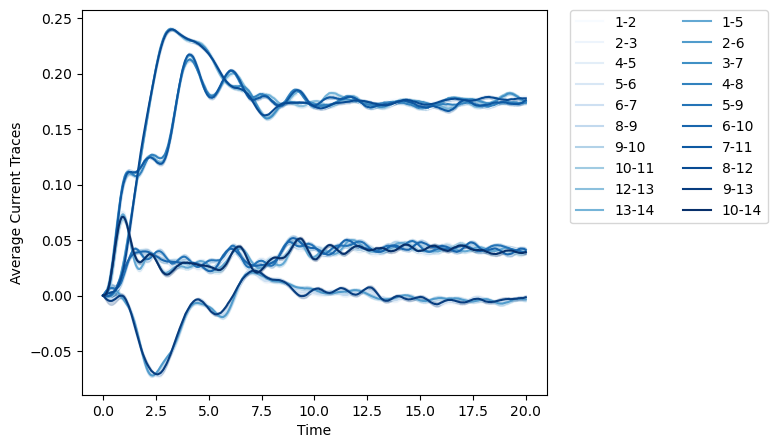

In [27]:
if path == '../data/data_numerics/':
    avg_currents = load_key_from_hdf5(path+filename, "avg_currents")
    currents_sq_avg = load_key_from_hdf5(path+filename, "currents_sq_avg")
    sem_currents_step = np.sqrt(currents_sq_avg - avg_currents**2)/np.sqrt(tot_shots)
    t_list = load_key_from_hdf5(path+filename, "t_list")

    plt.figure(figsize=(6,5))
    colors = plt.cm.Blues(np.linspace(0,1,20))
    for i, bond in enumerate(bonds):
        plt.fill_between(t_list, avg_currents[i,:] - sem_currents_step[i,:], avg_currents[i,:] + sem_currents_step[i,:], alpha=0.2, color=colors[i])
        plt.plot(t_list, avg_currents[i,:], label=f"{bond[0]}-{bond[1]}", color=colors[i])
    plt.xticks(fontsize= 10)
    plt.yticks(fontsize= 10)
    plt.xlabel("Time", fontsize=10)
    plt.ylabel("Average Current Traces", fontsize=10)

    # Legend on right outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol = 2,
            borderaxespad=0.)
    plt.show()


# Average Densities

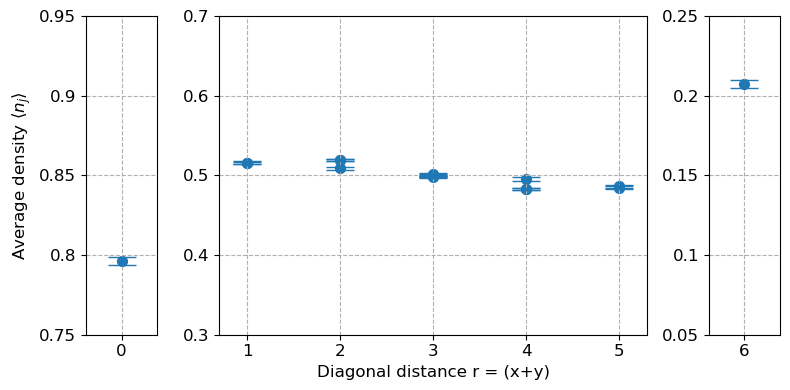

In [28]:
fig, ax = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 6, 1]}, figsize =(8, 4))

dist = [n//Nx + n%Nx for n in range(N)]  # Manhattan distance from source at (0,0)

ax[0].errorbar(dist[0], n_avg[0], yerr = n_sem[0], markersize = 0.1, capsize=10)
ax[0].scatter(dist[0], n_avg[0], marker='o', s= 50)
xlabels = np.arange(0, 1)
ylabels = np.round(np.arange(0.75, 1, 0.05), 3)
ax[0].set_xticks(xlabels)
ax[0].set_yticks(ylabels)
ax[0].set_xticklabels(xlabels, fontsize= 12)
ax[0].set_yticklabels(ylabels, fontsize= 12)

ax[1].errorbar(dist[1: 15], n_avg[1: 15], yerr = n_sem[1: 15], fmt = '.', markersize = 0.1, capsize=10)
ax[1].scatter(dist[1: 15], n_avg[1: 15], marker='o',s= 50)
xlabels = np.arange(1, 6)
ylabels = np.round(np.arange(0.3, 0.71, 0.1),3)
ax[1].set_xlim(0.7, 5.3)
ax[1].set_yticks(ylabels)
ax[1].set_xticks(xlabels)
ax[1].set_xticklabels(xlabels, fontsize= 12)
ax[1].set_yticklabels(ylabels, fontsize= 12)

ax[2].errorbar(dist[-1], n_avg[-1], yerr = n_sem[-1], fmt = '.', markersize = 0.5, capsize=10)
ax[2].scatter(dist[-1], n_avg[-1], marker='o', s= 50)
xlabels = np.arange(6, 7)
ylabels = np.round(np.arange(0.05, 0.3, 0.05), 3)
ax[2].set_xticks(xlabels)
ax[2].set_yticks(ylabels)
ax[2].set_yticklabels(ylabels, fontsize= 12)
ax[2].set_xticklabels(xlabels, fontsize= 12)


for a in ax:
    a.grid(linestyle = '--')
ax[0].set_ylabel(r"Average density $\langle n_{j} \rangle$", fontsize = 12)
ax[1].set_xlabel(r"Diagonal distance r = (x+y)", fontsize = 12)

fig.tight_layout()
# plt.savefig(f"figures/average_density_{statistics}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_tajectories{sample_shots}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=500)

# Density and Currrent Imbalances

### Single Simulation

In [29]:
edge_bonds = [[1, 2], [2, 3], [12, 13], [13, 14], [3, 7], [4, 8], [7, 11], [8, 12]] 
if type(bonds) != list:
    bonds = bonds.tolist()
DeltaN, std_density = density_imbalance(n_avg, n_sem)
DeltaJ, std_current = current_imbalance_edges(edge_bonds, bonds, currents, currents_sem)
print(f"{statistics} V={V}, phi={phi}:")
print("ΔN =", np.round(DeltaN, 3), "±", np.round(std_density, 3))
print("ΔJ =", np.round(DeltaJ, 3), "±", np.round(std_current, 3))

fermions V=0.0, phi=0.5:
ΔN = -0.003 ± 0.007
ΔJ = 0.004 ± 0.004


### All experimental cases

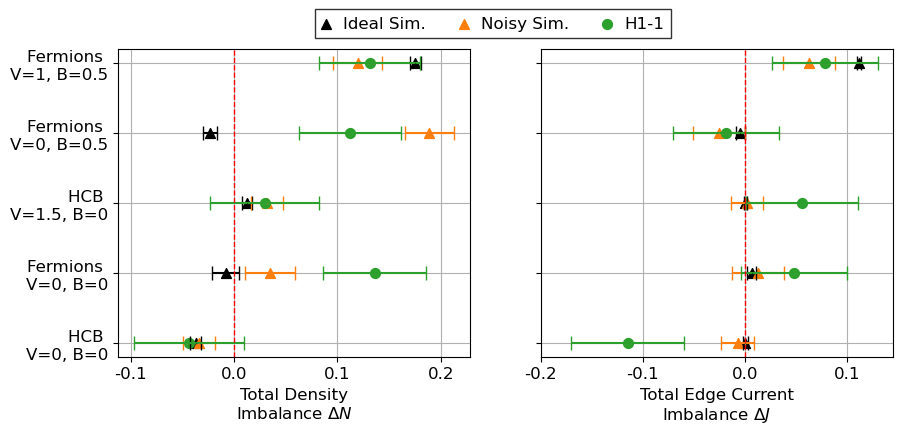

In [30]:
# calculate imbalances for all choices of V, phi and statistics
density_imbalances, current_imbalances = all_cases_imbalances('H1', [1280, 1480, 1280, 1480, 1480])
density_imbalances_E, current_imbalances_E = all_cases_imbalances('Noisy', [15000, 6250, 15000, 6250, 6250])
density_imbalances_ideal, current_imbalances_ideal = all_cases_imbalances('Ideal', [10000]*5)


# plot all imbalances (density + current)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize = (10, 4), sharey = True)

# define x and y axes
cases = ['HCB \nV=0, B=0', 'Fermions \nV=0, B=0', 'HCB \nV=1.5, B=0', 'Fermions \nV=0, B=0.5', 'Fermions \nV=1, B=0.5']
y = np.arange(1, len(cases)+1)
x1 = np.arange(-0.1, 0.25, 0.1)
x2 = np.arange(-0.2, 0.2, 0.1)

# Density imbalance subplot
ax1.scatter(density_imbalances_ideal[0, :], y, marker='^', s= 50, c = 'black', label = 'Ideal Sim.')
ax1.errorbar(density_imbalances_ideal[0, :], y, xerr = density_imbalances_ideal[1, :], c = 'black', fmt = '^', markersize = 0.1, capsize=5)
ax1.scatter(density_imbalances_E[0, :], y, marker='^', s= 50, c = 'C1', label = 'Noisy Sim.')
ax1.errorbar(density_imbalances_E[0, :], y, xerr = density_imbalances_E[1,:], c = 'C1', fmt = '^', markersize = 0.1, capsize=5)
ax1.scatter(density_imbalances[0, :], y, marker='o', s= 50, c = 'C2', label = 'H1-1')
ax1.errorbar(density_imbalances[0, :], y, xerr = density_imbalances[1,:], c = 'C2', fmt = 'o', markersize = 0.1, capsize=5)
ax1.axvline(x=0, color='r', linestyle='--', linewidth=1)
ax1.set_yticks(y, labels=cases, fontsize= 12)
ax1.set_xticks(x1, labels=x1, fontsize= 12)
ax1.set_xlabel(r'Total Density'+'\n'+r'Imbalance $\Delta N$', fontsize= 12)
ax1.grid()

# Current imbalance subplot
ax2.scatter(current_imbalances_ideal[0, :], y, marker='^', s= 50, c = 'black')
ax2.errorbar(current_imbalances_ideal[0, :], y, xerr = current_imbalances_ideal[1,:], c = 'black', fmt = '^', markersize = 0.1, capsize=5)
ax2.scatter(current_imbalances_E[0, :], y, marker='^', s= 50, c = 'C1')
ax2.errorbar(current_imbalances_E[0, :], y, xerr = current_imbalances_E[1,:], c = 'C1', fmt = '^', markersize = 0.1, capsize=5)
ax2.scatter(current_imbalances[0, :], y, marker='o', s= 50, c = 'C2')
ax2.errorbar(current_imbalances[0, :], y, xerr = current_imbalances[1,:], c = 'C2', fmt = 'o', markersize = 0.1, capsize=5)
ax2.axvline(x=0, color='r', linestyle='--', linewidth=1)
ax2.set_xticks(x2, labels=x2, fontsize= 12)
ax2.set_xlabel('Total Edge Current\n'+r'Imbalance $\Delta J$', fontsize= 12)
ax2.grid()

fig.legend(loc='upper center', fontsize = 12, bbox_to_anchor=(0.5, 1),
          ncol=3, fancybox=False, shadow=False, frameon=True, edgecolor='0', handlelength=0.5)
plt.show()

# Average Kraus Current

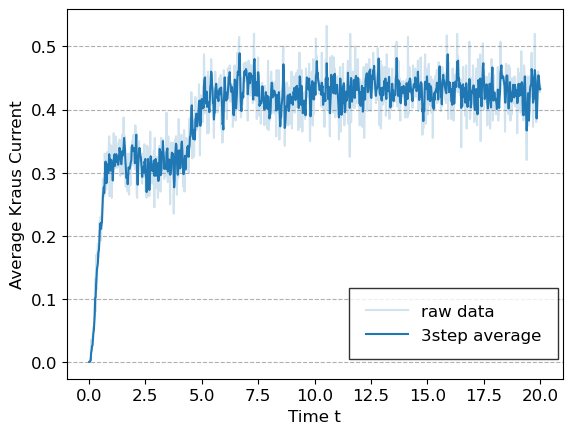

In [31]:
# average over final few steps
t_list = np.arange(0, (steps+1)*dt-1e-12, dt)

if path != '../data/data_numerics/':
    steps = load_key_from_hdf5(path+filename, 'parameters/steps')
    dt = load_key_from_hdf5(path+filename, 'parameters/dt')

    driving_current, inst_current = kraus_current(path, filename, sample_shots)
    yerr = np.std(inst_current, axis=0)/np.sqrt(inst_current.shape[0]) 
    current_cut, current_cut_sem  = current_cut_average(path, filename, statistics, sample_shots)

    plt.scatter(t_list[1:][-1], current_cut, alpha=1,  s= 100, label="H1")
    plt.errorbar(t_list[1:][-1], current_cut, yerr = current_cut_sem, c='C0', alpha=1, capsize=10)

else:
    K_avg = load_key_from_hdf5(f"../data/data_numerics/{filename}", "K_avg")
    driving_current = (K_avg[1,:] + K_avg[4,:] + K_avg[6,:] + K_avg[8,:] + 2*K_avg[7,:]) / 2

# calculate the cumulative average over the a 3 timesteps window
cum_av = [driving_current[0], (driving_current[0]+driving_current[1])/2]
window = 3
for j in range(3, len(driving_current)+1):
    cum_av.append(np.mean(driving_current[j-window:j]))
    
time = np.arange(0, 5.5, 0.53)
plt.plot(t_list[1:], driving_current/dt, c='C0', alpha=0.2, label="raw data")
plt.plot(t_list[1:], [i/dt for i in cum_av], c='C0', label="3step average")
plt.yticks(fontsize= 12)
plt.xticks(fontsize= 12)
plt.xlabel(r"Time t", fontsize= 12)
plt.ylabel("Average Kraus Current", fontsize= 12)
plt.grid(axis='y', linestyle = '--')
plt.legend(loc='lower center', fontsize =12, ncol = 1, bbox_to_anchor=(0.78, 0.03),
           fancybox=False, shadow=False, frameon=True, edgecolor='0', handlelength=2.5, borderpad=1)
plt.show()

# plt.savefig(f"../figures/average_krauscurrent.pdf", bbox_inches='tight', pad_inches=0.1, dpi=300)

# Average densities for same V and $\phi$

In [32]:
#  fix statistics, V and phi values
statistics = 'fermions'
V = 0.0
phi = 0.0

In [33]:
# load densities and currents from H1 data
path = '../data/data_H1/'
dt = 0.21
p = 2*dt
steps = 14
shots = 1480
filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{shots}.h5'
n_avg, n_sem, currents, currents_sem, bonds = get_device_observables(path, filename, statistics, shots)

# load densities and currents from Noisy Sim. data
path = '../data/data_Emulator/'
shots = 6500
sample_shots = 6250
filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{shots}.h5'
n_avg_E, n_sem_E, currents_E, currents_sem_E, bonds = get_device_observables(path, filename, statistics, sample_shots)

# load densities and currents from Ideal Sim. data
path = '../data/data_numerics/'
shots = 10000
filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{shots}_trotter.h5'
n_avg_ideal, n_sem_ideal, currents_ideal, currents_sem_ideal, bonds_ideal = get_numerics_observables(path, filename, shots)

# load densities and currents from Lindblad data
dt = 0.01
p = 2*dt
steps = 1000
filename = f'{statistics}_{start}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_shots{shots}.h5'
n_avg_lindblad, n_sem_lindblad, currents_lindblad, currents_sem_lindblad, bonds_lindblad = get_numerics_observables(path, filename, shots)

In [34]:
dist = [n//Nx + n%Nx for n in range(N)]  # Manhattan distance from source at (0,0)

# calculate average density as a function of Manhattan distance for n_avg from Lindblad.
n_T_lindblad = [0]*(max(dist)+1)
counter = [0]*(max(dist)+1)
for i in range(N):
    r = dist[i] 
    counter[dist[i]] += 1
    n_T_lindblad[dist[i]] += n_avg_lindblad[i]
n_T_lindblad = [n/r for n,r in zip(n_T_lindblad, counter)]

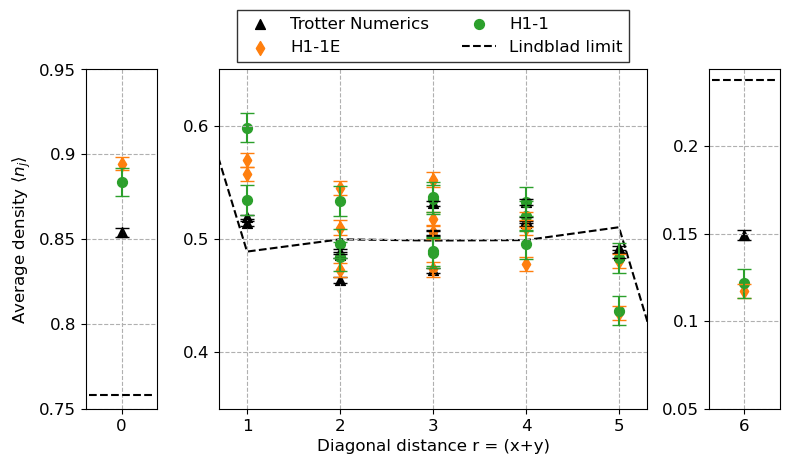

In [35]:
fig, ax = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 6, 1]}, figsize =(8, 4))

ax[0].plot([dist[0]-0.5, dist[0]+0.5], [n_T_lindblad[0], n_T_lindblad[0]], '--', c = 'black', label = 'Lindblad limit')
ax[0].errorbar(dist[0], n_avg_ideal[0], yerr = n_sem_lindblad[0], c = 'black', markersize = 0.1, capsize=5)
ax[0].scatter(dist[0], n_avg_ideal[0], c = 'black', marker='^', s= 50, label = 'Trotter Numerics')
ax[0].errorbar(dist[0], n_avg_E[0], yerr = n_sem_E[0], c = 'C1', markersize = 0.1, capsize=5)
ax[0].scatter(dist[0], n_avg_E[0], c = 'C1', marker='d',s= 50, label = 'H1-1E')
ax[0].errorbar(dist[0], n_avg[0], yerr = n_sem[0], c = 'C2', markersize = 0.1, capsize=5)
ax[0].scatter(dist[0], n_avg[0], c = 'C2', marker='o', s= 50, label = 'H1-1')
xlabels = np.arange(0, 1)
ylabels = np.round(np.arange(0.7, 1, 0.05), 3)
ax[0].set_xticks(xlabels)
ax[0].set_yticks(ylabels)
ax[0].set_yticklabels(ylabels, fontsize= 12)
ax[0].set_xticklabels(xlabels, fontsize= 12)
ax[0].set_ylim(0.75, 0.95)
ax[0].set_ylabel(r"Average density $\langle n_{j} \rangle$", fontsize = 12)

ax[1].errorbar(dist[1: 15], n_avg_ideal[1: 15], yerr = n_sem_lindblad[1: 15], fmt = '.', c = 'black', markersize = 0.1, capsize=5)
ax[1].scatter(dist[1: 15], n_avg_ideal[1: 15], c = 'black', marker='^', s= 50, label = 'Trotter Numerics')
ax[1].errorbar(dist[1: 15], n_avg_E[1: 15], yerr = n_sem_E[1: 15], fmt = '.', c = 'C1', markersize = 0.1, capsize=5)
ax[1].scatter(dist[1: 15], n_avg_E[1: 15], c = 'C1', marker='d',s= 50, label = 'H1-1E')
ax[1].errorbar(dist[1: 15], n_avg[1: 15], yerr = n_sem[1: 15], fmt = '.', c = 'C2', markersize = 0.1, capsize=5)
ax[1].scatter(dist[1: 15], n_avg[1: 15], c = 'C2', marker='o',s= 50, label = 'H1-1')
ax[1].plot(np.arange(0, 7), n_T_lindblad, '--', zorder=-2.5, c = 'black', label = 'Lindblad limit')
xlabels = np.arange(1, 6)
ylabels = np.round(np.arange(0.4, 0.65, 0.1),3)
ax[1].set_ylim(0.35, 0.65)
ax[1].set_xlim(0.7, 5.3)
ax[1].set_xticks(xlabels)
ax[1].set_yticks(ylabels)
ax[1].set_yticklabels(ylabels, fontsize= 12)
ax[1].set_xticklabels(xlabels, fontsize= 12)

ax[2].plot([dist[-1]-0.5, dist[-1]+0.5], [n_T_lindblad[-1], n_T_lindblad[-1]], '--', c = 'black', label = 'Lindblad limit')
ax[2].errorbar(dist[-1], n_avg_ideal[-1], yerr = n_sem_lindblad[-1], c = 'black', markersize = 0.1, capsize=5)
ax[2].scatter(dist[-1], n_avg_ideal[-1], c = 'black', marker='^', s= 50, label = 'Trotter Numerics')
ax[2].errorbar(dist[-1], n_avg_E[-1], yerr = n_sem_E[-1], fmt = '.', c = 'C1', markersize = 0.5, capsize=5)
ax[2].scatter(dist[-1], n_avg_E[-1], c = 'C1', marker='d', s= 50, label = 'H1-1E')
ax[2].errorbar(dist[-1], n_avg[-1], yerr = n_sem[-1], fmt = '.', c = 'C2', markersize = 0.5, capsize=5)
ax[2].scatter(dist[-1], n_avg[-1], c = 'C2', marker='o', s= 50, label = 'H1-1')
xlabels = np.arange(6, 7)
ylabels = np.round(np.arange(0.05, 0.25, 0.05), 3)
ax[2].set_xticks(xlabels)
ax[2].set_yticks(ylabels)
ax[2].set_yticklabels(ylabels, fontsize= 12)
ax[2].set_xticklabels(xlabels, fontsize= 12)

fig.tight_layout()
ax[1].legend(loc='upper center', fontsize = 12, bbox_to_anchor=(0.5, 1.2),
          ncol=2, fancybox=False, shadow=False, frameon=True, edgecolor='0')

for a in ax:
    a.grid(linestyle = '--')
ax[1].set_xlabel(r"Diagonal distance r = (x+y)", fontsize = 12)
plt.show()

# plt.savefig(f"../figures/average_density_{statistics}_V{V}_phi{phi}_dt{dt}_p{p}_steps{steps}_tajectories{shots}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=500)